1. import library

In [19]:
from bs4 import BeautifulSoup as bts
from bs4.element import Tag
from io import StringIO
import requests
import pandas as pd
import time
import seaborn as sns
import matplotlib.pyplot as plt

2. data scraping

In [6]:
headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/138.0.0.0 Safari/537.36"
    )
}

all_movies = []

for year in range(2000, 2026):

    print(f"Scraping {year}")

    try:
        url = f"https://en.wikipedia.org/wiki/List_of_American_films_of_{year}"

        response = requests.get(url,headers=headers)

        if response.status_code != 200:
            print(f"Gagal {year}: {response.status_code}")
            continue

        tables = pd.read_html(StringIO(response.text))

        for table in tables:
            cols = [str(c).lower() for c in table.columns]
            if ("title" in cols and "production company" in cols):
                table["Year"] = year
                all_movies.append(table)

        time.sleep(1)

    except Exception as e:
        print(f"Error {year}: {e}")

df = pd.concat(all_movies, ignore_index=True)
print(df.shape)

df.to_csv("american_movies_2000_2025.csv",index=False)

Scraping 2000
Scraping 2001
Scraping 2002
Scraping 2003
Scraping 2004
Scraping 2005
Scraping 2006
Scraping 2007
Scraping 2008
Scraping 2009
Scraping 2010
Scraping 2011
Scraping 2012
Scraping 2013
Scraping 2014
Scraping 2015
Scraping 2016
Scraping 2017
Scraping 2018
Scraping 2019
Scraping 2020
Scraping 2021
Scraping 2022
Scraping 2023
Scraping 2024
Scraping 2025
(6076, 9)


In [3]:
data = pd.read_csv("/home/hilal/kuliah/DM/Modul-DM-RKA/Materi/1 - Data Scraping & EDA/data/american_movies_2000_2025.csv")
data.head()

,Opening,Opening.1,Title,Production company,Cast and crew,Ref.,Year,Unnamed: 5,Production Company
0,J A N U A R Y,11.0,The Extreme Adventures of Super Dave,MGM Home Entertainment / Metro-Goldwyn-Mayer,"Peter MacDonald (director); Bob Einstein, Lorn...",NaN,2000,NaN,NaN
1,J A N U A R Y,12.0,Next Friday,New Line Cinema / Cube Vision,Steve Carr (director); Ice Cube (screenplay); ...,NaN,2000,NaN,NaN
2,J A N U A R Y,12.0,My Dog Skip,Warner Bros. Pictures / Alcon Entertainment,Jay Russell (director); Gail Gilchriest (scree...,NaN,2000,NaN,NaN
3,J A N U A R Y,14.0,Play It to the Bone,Touchstone Pictures,Ron Shelton (director/screenplay); Woody Harre...,NaN,2000,NaN,NaN
4,J A N U A R Y,14.0,Supernova,Metro-Goldwyn-Mayer,Walter Hill (director); David C. Wilson (scree...,NaN,2000,NaN,NaN


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6076 entries, 0 to 6075
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Opening             6073 non-null   object 
 1   Opening.1           5995 non-null   float64
 2   Title               5994 non-null   object 
 3   Production company  5776 non-null   object 
 4   Cast and crew       5992 non-null   object 
 5   Ref.                3325 non-null   object 
 6   Year                6076 non-null   int64  
 7   Unnamed: 5          0 non-null      float64
 8   Production Company  216 non-null    object 
dtypes: float64(2), int64(1), object(6)
memory usage: 427.3+ KB


In [5]:
data.shape

(6076, 9)

In [6]:
data.dtypes

Opening                object
Opening.1             float64
Title                  object
Production company     object
Cast and crew          object
Ref.                   object
Year                    int64
Unnamed: 5            float64
Production Company     object
dtype: object

3. analisis statistik dan kualitas data

In [7]:
data["Production company"] = (
    data["Production company"]
    .fillna(data["Production Company"])
)
data.drop(columns=["Production Company"], inplace=True)
data.drop(columns=["Ref."], inplace=True)
data.drop(columns=["Unnamed: 5"], inplace=True)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6076 entries, 0 to 6075
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Opening             6073 non-null   object 
 1   Opening.1           5995 non-null   float64
 2   Title               5994 non-null   object 
 3   Production company  5992 non-null   object 
 4   Cast and crew       5992 non-null   object 
 5   Year                6076 non-null   int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 284.9+ KB


In [9]:
data.isna().sum()

Opening                3
Opening.1             81
Title                 82
Production company    84
Cast and crew         84
Year                   0
dtype: int64

Opening = Ordinal
Opening.1 = Numerik diskrit
Title = Nominal
Production company = Nominal
Cast and Crew = Nominal
Year = Numerik diskrit

In [10]:
"""statistik deskriptif untuk atribut numerik"""
print(data.describe())

print("\nmodus opening.1: ", data["Opening.1"].mode())
print("median opening.1: ", data["Opening.1"].median())

print("\nmodus Year: ", data["Year"].mode())
print("median Year: ", data["Year"].median())

         Opening.1         Year
count  5995.000000  6076.000000
mean     15.929441  2012.802502
std       8.484506     7.559139
min       1.000000  2000.000000
25%       9.000000  2007.000000
50%      16.000000  2013.000000
75%      23.000000  2019.000000
max      31.000000  2025.000000

modus opening.1:  0    25.0
Name: Opening.1, dtype: float64
median opening.1:  16.0

modus Year:  0    2025
Name: Year, dtype: int64
median Year:  2013.0


In [11]:
"""Frekuensi untuk atribut kategorikal"""

print("frakuensi data kategorikal: ", data["Opening"].value_counts())
print("\nfrakuensi data kategorikal: ", data["Title"].value_counts().head(5))
print("\nfrekuensi data kategorikal: ", data["Production company"].value_counts().head(5))
print("\nfrekuensi data kategorikal: ", data["Cast and crew"].value_counts().head(5))

frakuensi data kategorikal:  Opening
O C T O B E R        609
D E C E M B E R      581
S E P T E M B E R    568
A U G U S T          560
M A R C H            530
A P R I L            520
N O V E M B E R      517
J U N E              475
M A Y                451
F E B R U A R Y      443
J U L Y              433
J A N U A R Y        369
N O V E M B E         16
27                     1
Name: count, dtype: int64

frakuensi data kategorikal:  Title
The Oath                          3
Stolen                            2
Death at a Funeral                2
The Polar Express (re-release)    2
Unknown                           2
Name: count, dtype: int64

frekuensi data kategorikal:  Production company
Lionsgate                   104
Netflix                      98
Fox Searchlight Pictures     91
Sony Pictures Classics       80
20th Century Fox             79
Name: count, dtype: int64

frekuensi data kategorikal:  Cast and crew
Robert Zemeckis (director/screenplay); William Broyles Jr. (screen

In [12]:
"""frekuensi data hilang"""
missing_percent = (data.isnull().sum()/len(data)*100)
print("\n")
print(missing_percent)



Opening               0.049375
Opening.1             1.333114
Title                 1.349572
Production company    1.382488
Cast and crew         1.382488
Year                  0.000000
dtype: float64


In [13]:
"""nambah data"""
data["panjang_judul"] = data["Title"].fillna("").astype(str).str.split().str.len()
data["panjang_cast"] = data["Cast and crew"].fillna("").astype(str).apply(len)
data["panjang_company"] = data["Production company"].fillna("").astype(str).apply(len)

In [14]:
print(data.info())
print(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6076 entries, 0 to 6075
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Opening             6073 non-null   object 
 1   Opening.1           5995 non-null   float64
 2   Title               5994 non-null   object 
 3   Production company  5992 non-null   object 
 4   Cast and crew       5992 non-null   object 
 5   Year                6076 non-null   int64  
 6   panjang_judul       6076 non-null   int64  
 7   panjang_cast        6076 non-null   int64  
 8   panjang_company     6076 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 427.3+ KB
None
         Opening  Opening.1                                 Title  \
0  J A N U A R Y       11.0  The Extreme Adventures of Super Dave   
1  J A N U A R Y       12.0                           Next Friday   
2  J A N U A R Y       12.0                           My Dog Skip   
3  J A N U

4. Visualisasi data

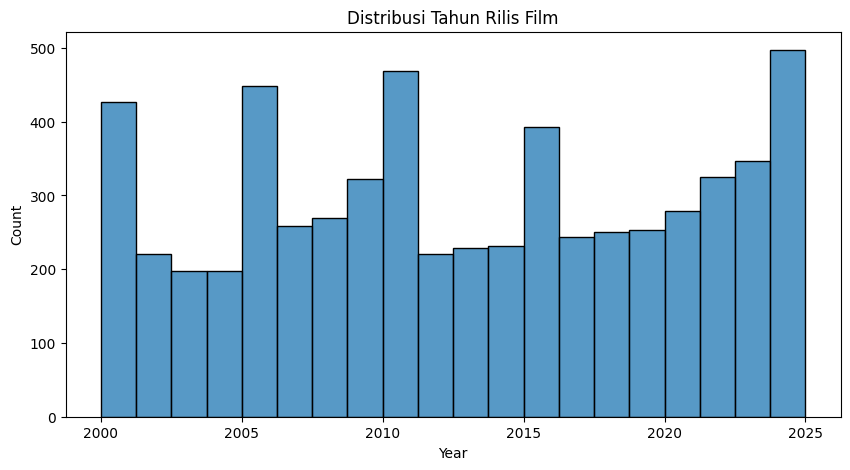

In [15]:
plt.figure(figsize=(10,5))
sns.histplot(data["Year"], bins=20)
plt.title("Distribusi Tahun Rilis Film")

plt.show()

mayoritas film dari periode tahun tertentu

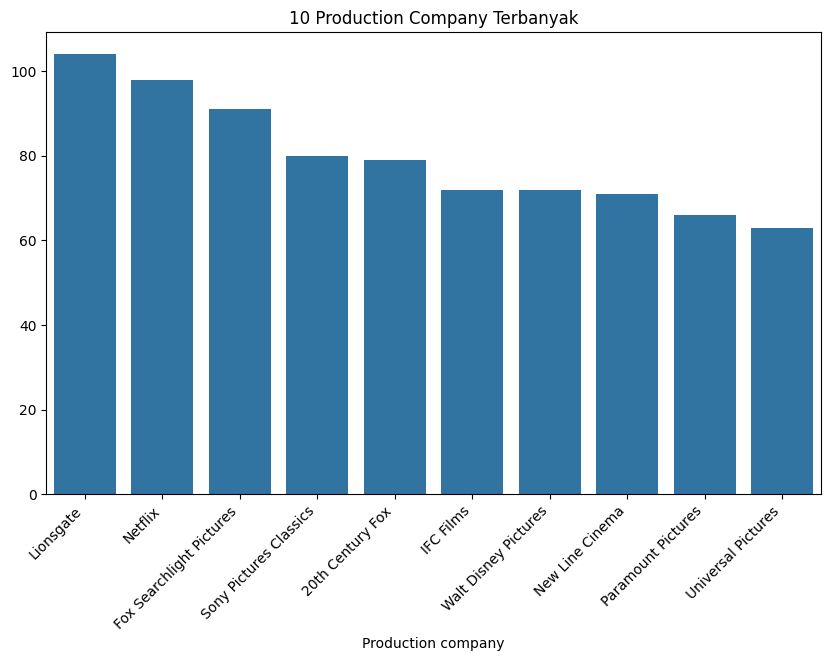

In [16]:
top_company = (data["Production company"].value_counts().head(10))
plt.figure(figsize=(10,6))
sns.barplot(x=top_company.index, y=top_company.values)
plt.title("10 Production Company Terbanyak")
plt.xticks(rotation=45, ha='right')

plt.show()

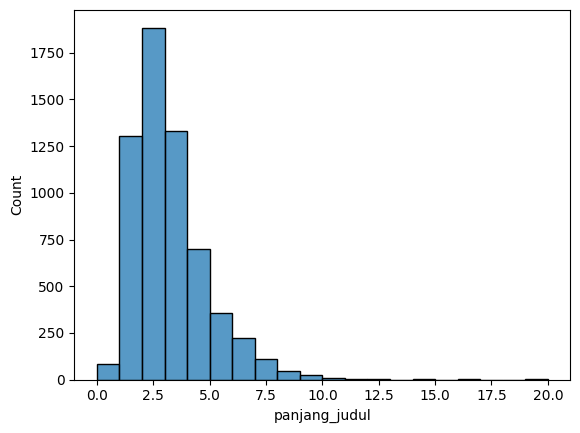

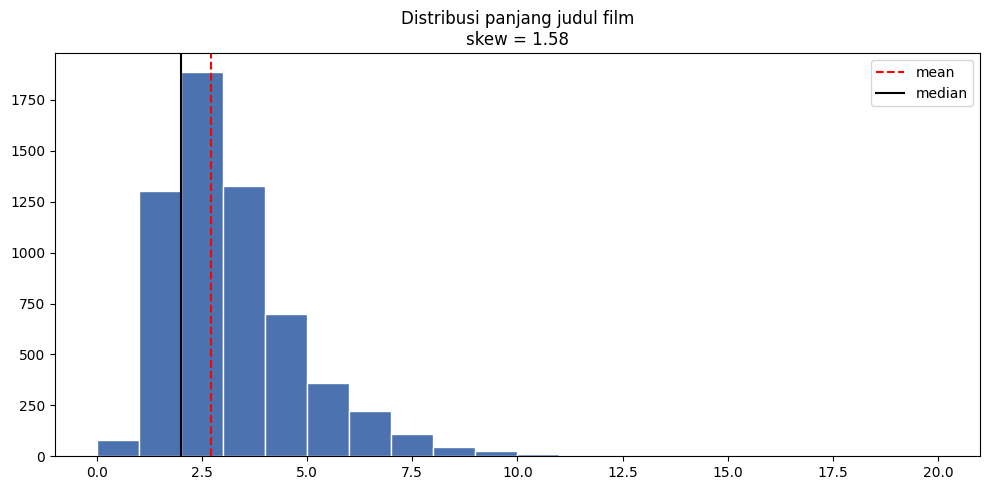

In [17]:
sns.histplot(data["panjang_judul"], bins= 20)
#plt.title("Distribusi panjang judul film")
fig, ax = plt.subplots(figsize=(10, 5))

series = data["panjang_judul"].dropna()

ax.hist(series, bins=20, color="#4C72B0", edgecolor="white")
ax.axvline(series.mean(), color="red", ls="--", label="mean")
ax.axvline(series.median(), color="black", ls="-", label="median")
ax.set_title(f"Distribusi panjang judul film\nskew = {series.skew():.2f}")
ax.legend()

plt.tight_layout()
#plt.show()
plt.tight_layout()

<Axes: xlabel='Year', ylabel='panjang_judul'>

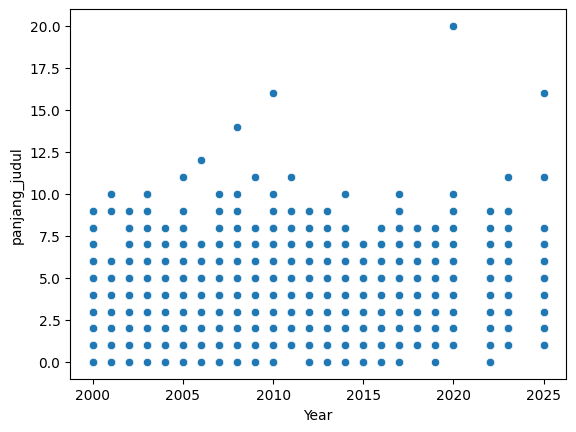

In [20]:
sns.scatterplot(data=data, x="Year", y="panjang_judul")

terlihat tidak ada hubungan kuat antara tahun rilis dengan panjang judul

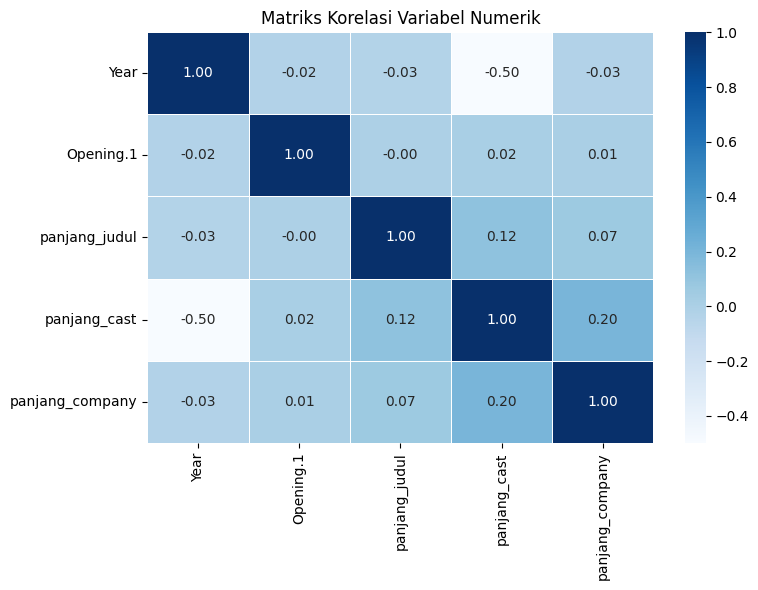

In [22]:
numerik = data[
    [
        "Year",
        "Opening.1",
        "panjang_judul",
        "panjang_cast",
        "panjang_company"
    ]
]

corr = numerik.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f", linewidths=0.5)
plt.title("Matriks Korelasi Variabel Numerik")
plt.tight_layout()
plt.show()

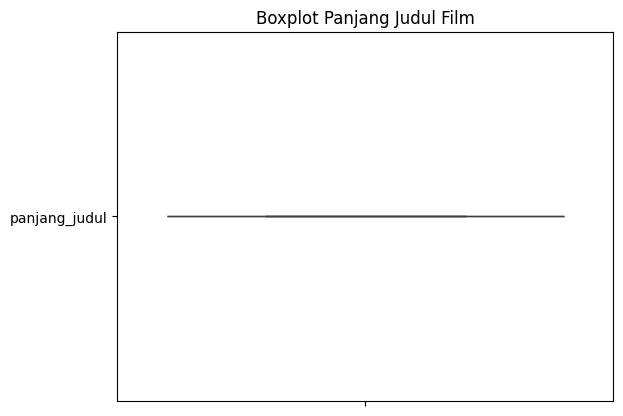

In [23]:
sns.boxplot(y=["panjang_judul"])
plt.title("Boxplot Panjang Judul Film")

plt.show()